In [1]:
#import psycopg2
from sqlalchemy import create_engine
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
database='postgres'
user='postgres'
password='postgres'
host='localhost'
port='5433'

engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")
query = "select * from fct__german_credit_wide"

df = pd.read_sql(query, engine)
df.risk = df.risk.map({1:'good',0:'bad'})

In [3]:
df.head()

,id,risk,age,sex,duration_months,credit_amount,log_credit_amount,credit_exposure,credit_per_age_year,monthly_payment_estimate,...,has_no_checking_info,saving_accounts,checking_account,job_skill_level,housing_stability_score,stable_profile_flag,high_risk_profile_flag,housing,purpose,purpose_risk_group
0,1,good,67,male,6,1169,7.063904,7014,17,194,...,0,NaN,little,2,2,1,0,own,radio/TV,consumer
1,2,bad,22,female,48,5951,8.691315,285648,270,123,...,0,little,moderate,2,2,1,0,own,radio/TV,consumer
2,3,good,49,male,12,2096,7.647786,25152,42,174,...,1,little,NaN,1,2,0,0,own,education,investment
3,4,good,45,male,42,7882,8.972337,331044,175,187,...,0,little,little,2,1,0,0,free,furniture/equipment,asset_backed
4,5,bad,53,male,24,4870,8.490849,116880,91,202,...,0,little,little,2,1,0,0,free,car,asset_backed


In [4]:
print("Rows: ",df.shape[0])
print("Columns: ",df.shape[1])

Rows:  1000
Columns:  25


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        1000 non-null   int64  
 1   risk                      1000 non-null   str    
 2   age                       1000 non-null   int64  
 3   sex                       1000 non-null   str    
 4   duration_months           1000 non-null   int64  
 5   credit_amount             1000 non-null   int64  
 6   log_credit_amount         1000 non-null   float64
 7   credit_exposure           1000 non-null   int64  
 8   credit_per_age_year       1000 non-null   int64  
 9   monthly_payment_estimate  1000 non-null   int64  
 10  loan_term_tier            1000 non-null   str    
 11  savings_score             1000 non-null   int64  
 12  checking_score            1000 non-null   int64  
 13  total_liquidity_score     1000 non-null   int64  
 14  has_no_savings_info 

In [6]:
df.nunique()

id                          1000
risk                           2
age                           53
sex                            2
duration_months               33
credit_amount                921
log_credit_amount            921
credit_exposure              977
credit_per_age_year          265
monthly_payment_estimate     317
loan_term_tier                 3
savings_score                  4
checking_score                 4
total_liquidity_score          8
has_no_savings_info            2
has_no_checking_info           2
saving_accounts                4
checking_account               3
job_skill_level                4
housing_stability_score        3
stable_profile_flag            2
high_risk_profile_flag         2
housing                        3
purpose                        8
purpose_risk_group             6
dtype: int64

In [7]:
df.describe()

,id,age,duration_months,credit_amount,log_credit_amount,credit_exposure,credit_per_age_year,monthly_payment_estimate,savings_score,checking_score,total_liquidity_score,has_no_savings_info,has_no_checking_info,job_skill_level,housing_stability_score,stable_profile_flag,high_risk_profile_flag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.546000,20.903000,3271.258000,7.788691,89631.582000,99.008000,167.206000,1.001000,1.001000,2.002000,0.18300,0.394000,1.904000,1.534000,0.546000,0.031000
std,288.819436,11.375469,12.058814,2822.736876,0.776474,128338.181915,91.237493,153.487504,0.884184,0.957034,1.346778,0.38686,0.488879,0.653614,0.779392,0.498129,0.173404
min,1.000000,19.000000,4.000000,250.000000,5.521461,1500.000000,6.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,27.000000,12.000000,1365.500000,7.219276,17796.000000,40.000000,89.000000,1.000000,0.000000,1.000000,0.00000,0.000000,2.000000,1.000000,0.000000,0.000000
50%,500.500000,33.000000,18.000000,2319.500000,7.749107,40128.000000,68.000000,130.000000,1.000000,1.000000,2.000000,0.00000,0.000000,2.000000,2.000000,1.000000,0.000000
75%,750.250000,42.000000,24.000000,3972.250000,8.287088,98748.000000,127.250000,206.000000,1.000000,2.000000,3.000000,0.00000,1.000000,2.000000,2.000000,1.000000,0.000000
max,1000.000000,75.000000,72.000000,18424.000000,9.821409,939180.000000,745.000000,2482.000000,4.000000,3.000000,7.000000,1.00000,1.000000,3.000000,2.000000,1.000000,1.000000


In [8]:
for col in df.select_dtypes(exclude=['number']).columns:
    print('-------------------------------------')
    print(f'Categories in {col}:')
    print(list(df[col].unique()))

-------------------------------------
Categories in risk:
['good', 'bad']
-------------------------------------
Categories in sex:
['male', 'female']
-------------------------------------
Categories in loan_term_tier:
['short', 'long', 'medium']
-------------------------------------
Categories in saving_accounts:
[nan, 'little', 'quite rich', 'rich', 'moderate']
-------------------------------------
Categories in checking_account:
['little', 'moderate', nan, 'rich']
-------------------------------------
Categories in housing:
['own', 'free', 'rent']
-------------------------------------
Categories in purpose:
['radio/TV', 'education', 'furniture/equipment', 'car', 'business', 'domestic appliances', 'repairs', 'vacation/others']
-------------------------------------
Categories in purpose_risk_group:
['consumer', 'investment', 'asset_backed', 'productive', 'maintenance', 'other']


In [9]:
m = len(df)
for col in df.select_dtypes(exclude=['number']).columns:
    print('-------------------------------------')
    print(f'Distribution for {col}:')
    print(df.groupby(col)['id'].count()*100/m)

-------------------------------------
Distribution for risk:
risk
bad     30.0
good    70.0
Name: id, dtype: float64
-------------------------------------
Distribution for sex:
sex
female    31.0
male      69.0
Name: id, dtype: float64
-------------------------------------
Distribution for loan_term_tier:
loan_term_tier
long      23.0
medium    41.1
short     35.9
Name: id, dtype: float64
-------------------------------------
Distribution for saving_accounts:
saving_accounts
little        60.3
moderate      10.3
quite rich     6.3
rich           4.8
Name: id, dtype: float64
-------------------------------------
Distribution for checking_account:
checking_account
little      27.4
moderate    26.9
rich         6.3
Name: id, dtype: float64
-------------------------------------
Distribution for housing:
housing
free    10.8
own     71.3
rent    17.9
Name: id, dtype: float64
-------------------------------------
Distribution for purpose:
purpose
business                9.7
car              

#### 1. General Creditability Distribution

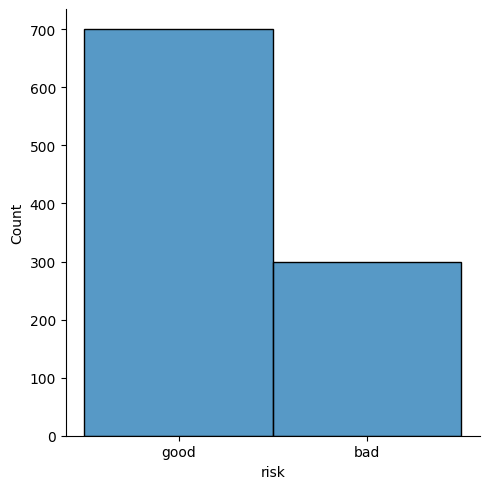

In [10]:
sns.displot(df,x='risk')
plt.show()

#### 2. Numerical Variables in Relation to Creditability

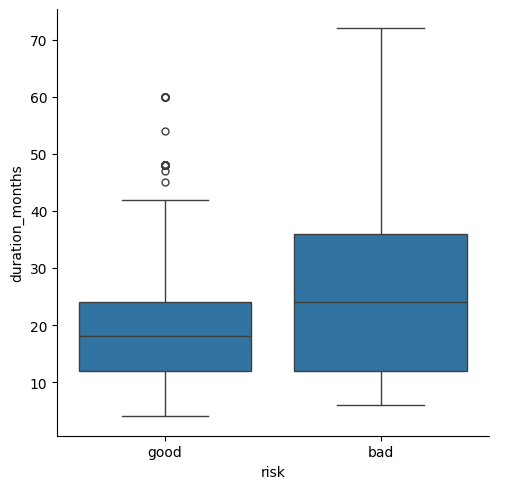

In [11]:
sns.catplot(
    data=df, x='risk', y='duration_months',
    kind="box"
)
plt.show()

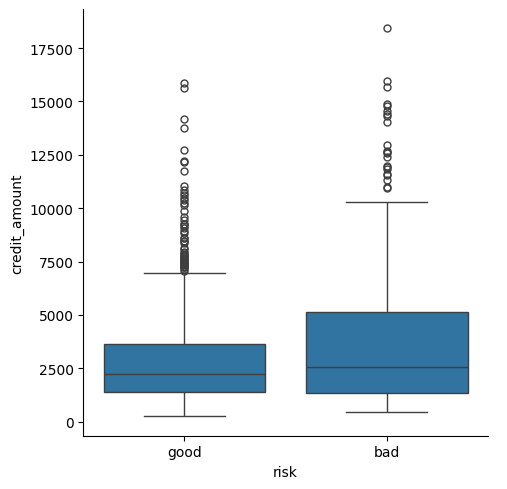

In [12]:
sns.catplot(
    data=df, x="risk", y='credit_amount',
    kind="box"
)
plt.show()

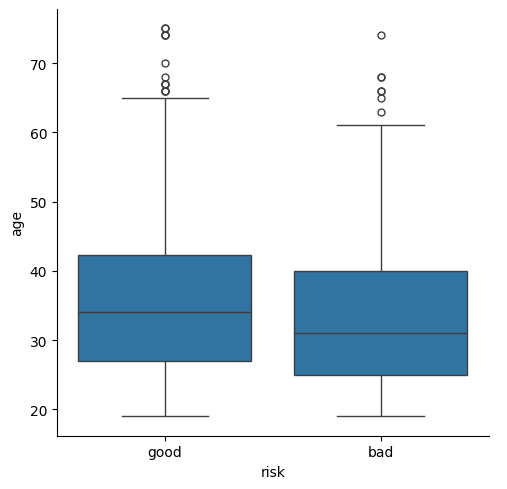

In [13]:
sns.catplot(
    data=df, x="risk", y='age',
    kind="box"
)
plt.show()

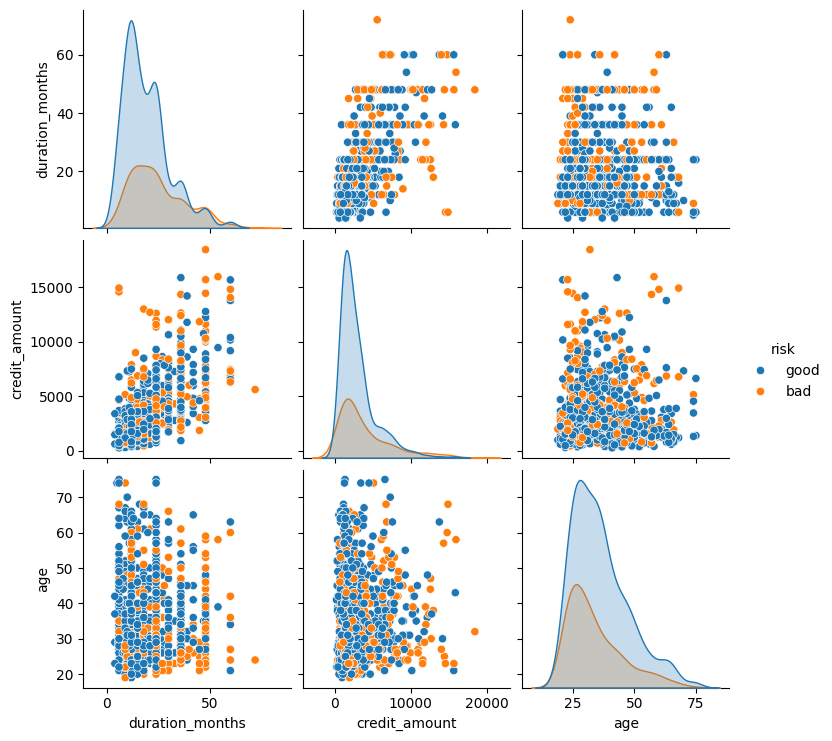

In [14]:
sns.pairplot(df[['duration_months','credit_amount','age','risk']],hue='risk')
plt.show()

#### 3. Crosstab Risk to Categorical Features

In [15]:
df

,id,risk,age,sex,duration_months,credit_amount,log_credit_amount,credit_exposure,credit_per_age_year,monthly_payment_estimate,...,has_no_checking_info,saving_accounts,checking_account,job_skill_level,housing_stability_score,stable_profile_flag,high_risk_profile_flag,housing,purpose,purpose_risk_group
0,1,good,67,male,6,1169,7.063904,7014,17,194,...,0,NaN,little,2,2,1,0,own,radio/TV,consumer
1,2,bad,22,female,48,5951,8.691315,285648,270,123,...,0,little,moderate,2,2,1,0,own,radio/TV,consumer
2,3,good,49,male,12,2096,7.647786,25152,42,174,...,1,little,NaN,1,2,0,0,own,education,investment
3,4,good,45,male,42,7882,8.972337,331044,175,187,...,0,little,little,2,1,0,0,free,furniture/equipment,asset_backed
4,5,bad,53,male,24,4870,8.490849,116880,91,202,...,0,little,little,2,1,0,0,free,car,asset_backed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,good,31,female,12,1736,7.459339,20832,56,144,...,1,little,NaN,1,2,0,0,own,furniture/equipment,asset_backed
996,997,good,40,male,30,3857,8.257645,115710,96,128,...,0,little,little,3,2,1,0,own,car,asset_backed
997,998,good,38,male,12,804,6.689599,9648,21,67,...,1,little,NaN,2,2,1,0,own,radio/TV,consumer
998,999,bad,23,male,45,1845,7.520235,83025,80,41,...,0,little,little,2,1,0,0,free,radio/TV,consumer


In [19]:
for col in df.select_dtypes(exclude=['number']).columns:
    print(f"Crosstab {col} to risk\n")
    res = pd.crosstab(df['risk'],df[col])
    print(res)
    print("--------------------------")

Crosstab risk to risk

risk  bad  good
risk           
bad   300     0
good    0   700
--------------------------
Crosstab sex to risk

sex   female  male
risk              
bad      109   191
good     201   499
--------------------------
Crosstab loan_term_tier to risk

loan_term_tier  long  medium  short
risk                               
bad              102     122     76
good             128     289    283
--------------------------
Crosstab saving_accounts to risk

saving_accounts  little  moderate  quite rich  rich
risk                                               
bad                 217        34          11     6
good                386        69          52    42
--------------------------
Crosstab checking_account to risk

checking_account  little  moderate  rich
risk                                    
bad                  135       105    14
good                 139       164    49
--------------------------
Crosstab housing to risk

housing  free  own  rent
risk       